In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

#load data
df = pd.read_csv('../data/raw/nab/machine_temperature_system_failure.csv', parse_dates=['timestamp'], index_col='timestamp')

print(df.shape)
print(df.describe())
print(df.isnull().sum())

(22695, 1)
              value
count  22695.000000
mean      85.926498
std       13.746912
min        2.084721
25%       83.080078
50%       89.408246
75%       94.016252
max      108.510543
value    0
dtype: int64


In [7]:
with open('data/raw/nab/combined_windows.json') as f:
    windows = json.load(f)

anomaly_windows = windows['realKnownCause/machine_temperature_system_failure.csv']
print(anomaly_windows)


[['2013-12-10 06:25:00.000000', '2013-12-12 05:35:00.000000'], ['2013-12-15 17:50:00.000000', '2013-12-17 17:00:00.000000'], ['2014-01-27 14:20:00.000000', '2014-01-29 13:30:00.000000'], ['2014-02-07 14:55:00.000000', '2014-02-09 14:05:00.000000']]


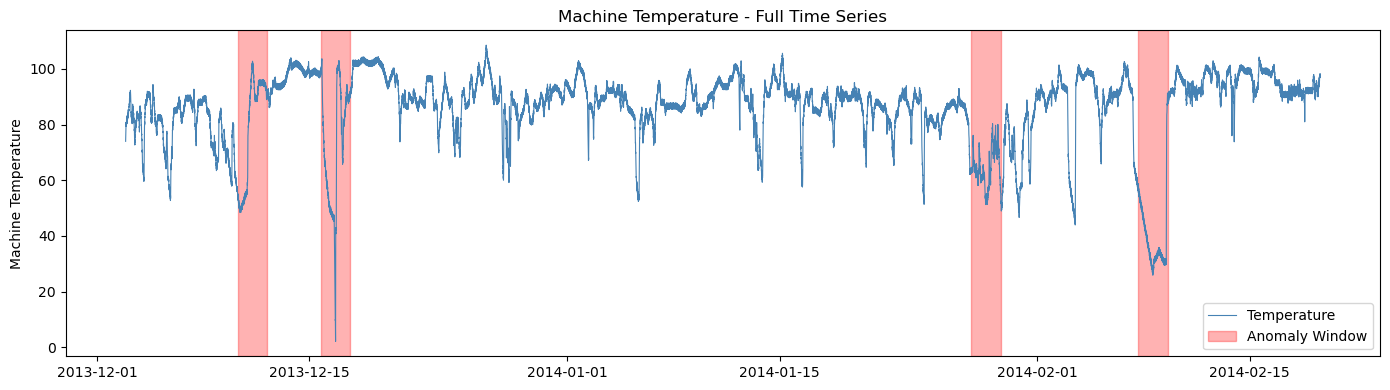

In [22]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df.index, df['value'], color='steelblue', linewidth=0.8, label='Temperature')

for i, window in enumerate(anomaly_windows):
    ax.axvspan(pd.Timestamp(window[0]), pd.Timestamp(window[1]), alpha=0.3,color='red', label='Anomaly Window' if i == 0 else None)
ax.set_title('Machine Temperature - Full Time Series')
ax.set_ylabel('Machine Temperature')
ax.legend()
plt.tight_layout()
plt.show()

# EDA- Machine Temperature Time Series
The dataset contains 22,695 timesteps of machine temperature reading with 4 labelled anomaly windows.

**Visual observations:**
1) The temperature shows periodic patterns during normal operations.
2) The anomaly windows correspond to visible disruptions in the temperature.
3) The anomalies appear as sharp increases in temperature, sparp declines in temperature, both sparp decline and increase in temperature and as extended period of lowered temperatures readings.

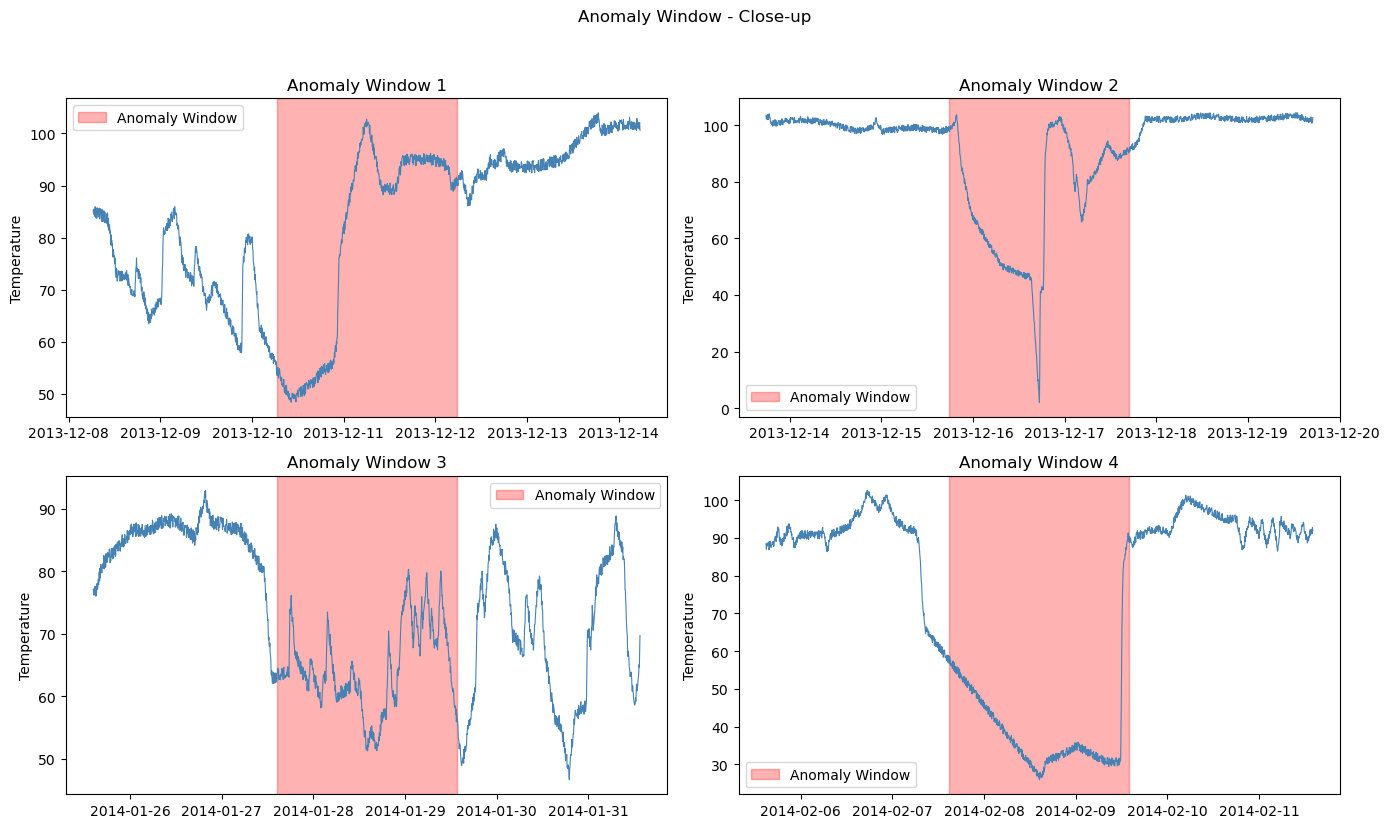

In [16]:
#Ploting each anomaly window closely
fig, axes = plt.subplots(2,2,figsize=(14,8))
axes = axes.flatten()
for i, window in enumerate(anomaly_windows):
    start = pd.Timestamp(window[0]) - pd.Timedelta(days = 2)
    end   = pd.Timestamp(window[1]) + pd.Timedelta(days = 2)

    subset = df[start:end]
    axes[i].plot(subset.index, subset['value'], color='steelblue', linewidth=0.8)
    axes[i].axvspan(pd.Timestamp(window[0]), pd.Timestamp(window[1]), alpha = 0.3, color = 'red',label='Anomaly Window')
    axes[i].set_title(f'Anomaly Window {i+1}')
    axes[i].set_ylabel('Temperature')
    axes[i].legend()

plt.suptitle('Anomaly Window - Close-up', y=1.03)
plt.tight_layout()
plt.show()

# Anomaly window analysis - Close-up

**Each anomaly has a distinct pattern**:
1) Sharp temperature increase.
2) Decline folowd by sharp decline witch then is followed by a sharp increase.
3) Extended period on underperformance followed by return to normal (better seen in the zoom-out version).
4) Sharp decline followed by sharp increase.

This suggest theanomalies are not of the same type as we have spikes(both downward and upwards) , sustained degradation periods and underperformance.
The autoencoder will need toi detect all types of anomalies from the reconstruction error alone, without any labels during training

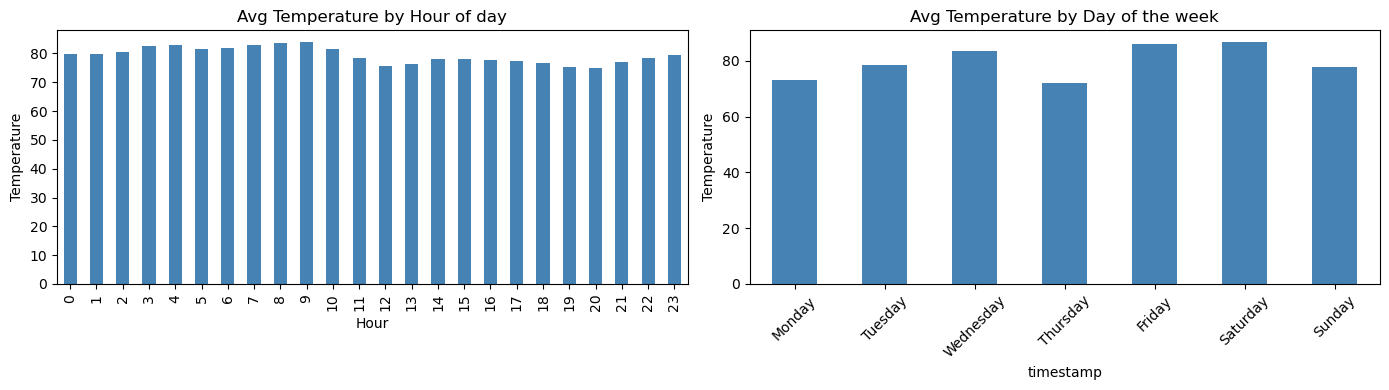

In [29]:
#checking for normal pattern in data
#First isolation of normal data before first anomaly
normal_df=df[df.index<pd.Timestamp(anomaly_windows[0][0])]

#First pattern check daily= avg temp by hour of day
fig, axes = plt.subplots(1, 2, figsize=(14,4))

normal_df.groupby(normal_df.index.hour)['value'].mean().plot(kind='bar', ax=axes[0], color='steelblue', title='Avg Temperature by Hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Temperature')

#Pattern check weekly= avg temp by day of the week 
normal_df.groupby(normal_df.index.dayofweek)['value'].mean().plot(kind='bar', ax=axes[1], color='steelblue', title='Avg Temperature by Day of the week')
axes[1].set_xticklabels(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], rotation=45)
axes[1].set_ylabel('Temperature')

plt.tight_layout()
plt.show()

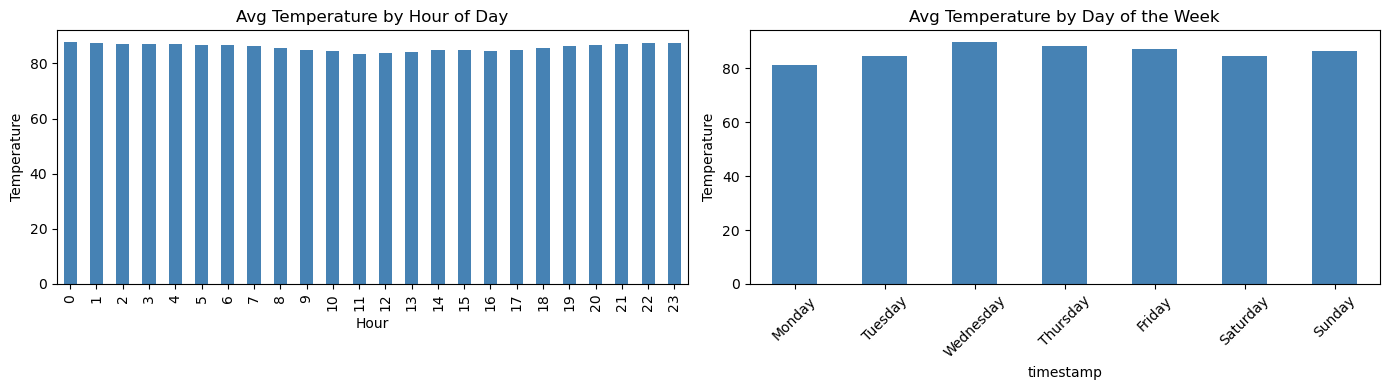

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Daily pattern
df.groupby(df.index.hour)['value'].mean().plot(kind='bar', ax=axes[0], color='steelblue', title='Avg Temperature by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Temperature')

# Weekly pattern
df.groupby(df.index.dayofweek)['value'].mean().plot(kind='bar', ax=axes[1], color='steelblue', title='Avg Temperature by Day of the Week')
axes[1].set_xticklabels(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], rotation=45)
axes[1].set_ylabel('Temperature')

plt.tight_layout()
plt.show()

# Seasonality analysis

**Daily pattern:**
1) Peak at 22-00.
2) Continuous decline to minimum around 11.
3) Gradual increas through the afternoon back to peak at 22.

**Weekly pattern:**
1) Monday to Wednesday: increasing trend.
2) Thursday to Saturday: continued decline.
3) Sunday: increase
4) Monday: decrease from Sunday.

These patterns represent normal machine temperature bhavius. The auto encoder will learn these rhythms during training and flag deviations from them as anomalies.

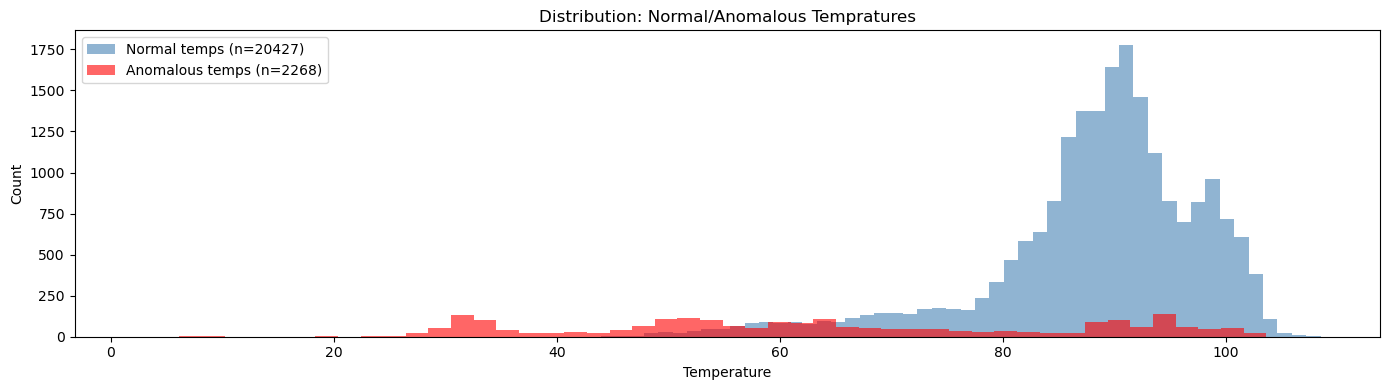

Normal mean: 88.36, std: 9.79
Anomalous mean: 64.02, std: 22.25


In [39]:
#anomaly mask
is_anomaly = pd.Series(False, index = df.index)

for window in anomaly_windows:
    start = pd.Timestamp(window[0])
    end   = pd.Timestamp(window[1])
    is_anomaly[(df.index>=start) & (df.index<=end)] = True

normal_temps = df[~is_anomaly]['value']
anomaly_temps = df[is_anomaly]['value']

# distribution plots
fig, ax = plt.subplots(figsize=(14,4))
ax.hist(normal_temps, bins=50, alpha=0.6, color='steelblue', label=f'Normal temps (n={len(normal_temps)})')
ax.hist(anomaly_temps, bins=50, alpha=0.6, color='red', label=f'Anomalous temps (n={len(anomaly_temps)})')
ax.set_title('Distribution: Normal/Anomalous Tempratures')
ax.set_xlabel('Temperature')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Normal mean: {normal_temps.mean():.2f}, std: {normal_temps.std():.2f}')
print(f'Anomalous mean: {anomaly_temps.mean():.2f}, std: {anomaly_temps.std():.2f}')

## Normal / Anomaouls Distribution

The two populations are cleary distinct:
1) Normal mean: 88.36, std:9,79 that means that there is a tight distribution when in stable operation.
2) Anomalous mean: 64.02, std:22.25 that means that we have a wide spread and a lower mean.

The anomalous std is more than double the normal std, confirming high instability during failure periods. The autoencoder will learn the tight normal distribution and flag the wide anomalous deviations via high reconstruction error.